# Comparative Analysis of Machine Learning Algorithms for Alzheimer’s Disease Prediction

## Dataset Overview

The `Alzheimer_dataset` was selected for the **AML-Advance** project. It was sourced from `Kaggle` website and includes comprehensive demographic and clinical health features used for Alzheimer’s Disease prediction.

- **Total patients**:   2,149
- **Total features:** 36 variables spanning multiple domains including demographic, lifestyle, clinical, cognitive, and functional assessment data.
- Contains **missing values (NaN)** in some features.
- The dataset is imbalanced, with **1,389** healthy cases and **760** Alzheimer’s cases.
- **Target variable:** Diagnosis (**0 = Healthy, 1 = Alzheimer’s Disease**)

## Objectives

- Conduct **exploratory data analysis (EDA)** and perform necessary **data preprocessing.**
- Handle **missing values (NaN),** **class imbalance** and apply **feature selection techniques** to identify the most relevant predictors.
- Develop and train multiple machine learning models, including:
**1. Support Vector Machine (SVM)**,
**2. Random Forest (RF)**,
**3. Logistic Regression (LR)**, and
**4. XGBoost (XGB) Classifier**.
- Optimize model performance using **GridSearchCV and k-fold cross-validation.**
- Evaluate model performance using **Accuracy, Precision, Recall, F1-score, Confusion Matrix,** and **ROC-AUC Score.**
- Perform a **comparative analysis** of all models to identify the best-performing classifier for **Alzheimer’s Disease prediction.**

***Note:*** The notebook is structured using a combination of Markdown description and executable code blocks to ensure clarity, readability, and reproducibility of the analysis.

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

# **Load Dataset**

In [2]:
df = pd.read_csv('Alzheimer_dataset.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge,FunctionalAssessment
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,1.725883,0,0,0,1,0,0,XXXConfid,NaN
1,4752,89,0,0,0,26.827681,0,4.542524,NaN,0.518767,...,0,2.592424,0,0,0,0,1,0,XXXConfid,NaN
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,7.119548,0,1,0,1,0,0,XXXConfid,NaN
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,1,6.481226,0,0,0,0,0,0,XXXConfid,NaN
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0.014691,0,0,1,1,0,0,NaN,NaN


# **Exploratory Data Analysis**

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        1849 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           1849 non-null   float64
 9   DietQuality                1849 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,FunctionalAssessment
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,1849.000000,2149.000000,2149.000000,1849.000000,1849.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,0.0
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.631237,0.288506,11.168416,4.956379,4.994510,...,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653,NaN
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.207233,0.453173,7.714394,2.857908,2.939972,...,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214,NaN
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.495904,0.000000,5.315086,2.590615,2.395883,...,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.803264,0.000000,10.327728,4.789175,5.079624,...,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.817008,1.000000,15.809404,7.455434,7.588054,...,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,39.832637,9.987429,9.998346,...,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN


**Description**

- Dataset has **2,149** samples and **36** features with mixed data types and some **missing values**, including one invalid column `FunctionalAssessment`.
- Features are on different scales,e.g` BMI (mean ≈ 27.6)` , `Alcohol Consumption (mean ≈ 11.2)` and `ADL (mean ≈ 4.98)` so **standardization** is required before modeling.
- Target variable **(Diagnosis)** is already encoded in dataset `(0 = Healthy, 1 = Alzheimer’s Disease)`.

# **Check missing values**

In [4]:
print(df.isnull().sum())

PatientID                       0
Age                             0
Gender                          0
Ethnicity                       0
EducationLevel                  0
BMI                           300
Smoking                         0
AlcoholConsumption              0
PhysicalActivity              300
DietQuality                   300
SleepQuality                    0
FamilyHistoryAlzheimers         0
CardiovascularDisease           0
Diabetes                        0
Depression                      0
HeadInjury                      0
Hypertension                    0
SystolicBP                      0
DiastolicBP                     0
CholesterolTotal              300
CholesterolLDL                  0
CholesterolHDL                  0
CholesterolTriglycerides        0
MMSE                            0
FunctionalAssessment            0
MemoryComplaints                0
BehavioralProblems              0
ADL                             0
Confusion                       0
Disorientation

**Description**

- The dataset contains missing values in multiple features, such as `BMI`, `PhysicalActivity`, `DietQuality`, `CholesterolTotal`, and `DoctorInCharge` (≈300 missing each).
- The feature `FunctionalAssessment` is completely missing (2149 null values) and is not usable.
- These missing values require imputation or removal before model training to ensure data quality.

# **Data cleaning & handle missing values**

In [5]:
# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Drop completely empty columns
df.dropna(axis=1, how='all', inplace=True)

# Drop irrelevant column
df.drop(columns=['DoctorInCharge', 'PatientID'], errors='ignore', inplace=True)

# Handle missing values
num_cols = ['BMI', 'PhysicalActivity', 'DietQuality', 'CholesterolTotal']

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Final check
print(df.isnull().sum())

Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfulness                0
Diagnosi

**Description**
  
- Duplicate and empty columns were removed, and the Missing values in numerical features were handled using median imputation.
- `PatientID` and `DoctorInCharge` were removed because it does not contribute any predictive information for the model or may overfit or learn meaningless pattern.
- After preprocessing, the dataset is fully clean with no missing values, making it suitable for model training.

# **Class distribution of target variable**

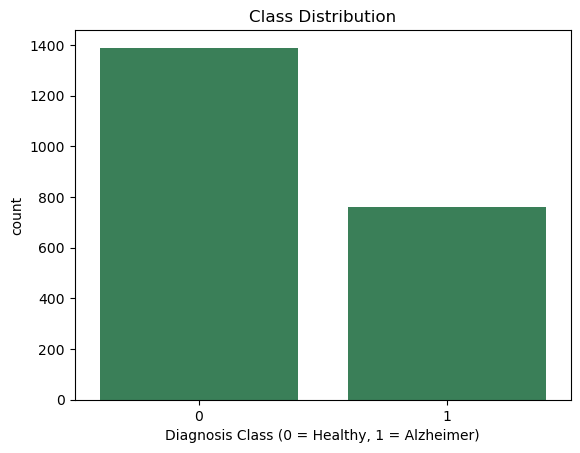

Diagnosis
0    1389
1     760
Name: count, dtype: int64
Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64


In [6]:
sns.countplot(x='Diagnosis', data=df, color="seagreen")
plt.title("Class Distribution")
plt.xlabel("Diagnosis Class (0 = Healthy, 1 = Alzheimer)")
plt.savefig("diagnosis_class_distribution.png", dpi=300)
plt.show()

print(df['Diagnosis'].value_counts())
print(df['Diagnosis'].value_counts(normalize=True))

**Description**

- The count plot shows the **distribution of the target variable (Diagnosis)** in the dataset.
- The target variable shows a **moderate class imbalance (~65% healthy vs ~35% Alzheimer’s cases)**, To handle this, class weights (e.g., `class_weight='balanced'`) or resampling techniques can be used during model training to reduce bias toward the majority class.

## **Example of Univariate Distribution (Histogram)**
To understand how individual features are distributed, histograms are plotted for selected variables.

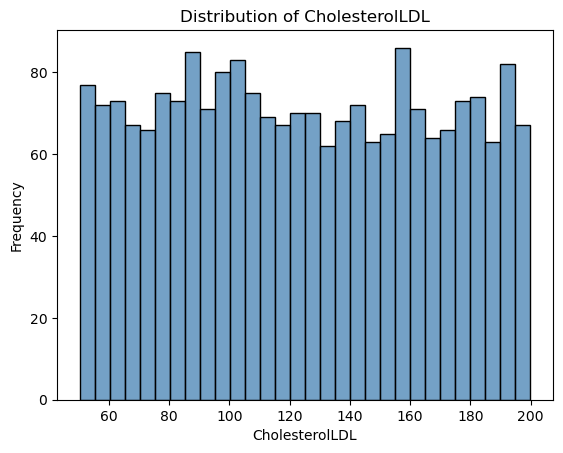

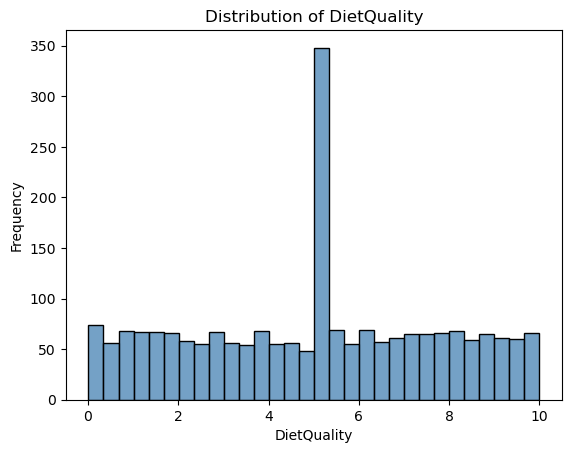

In [7]:
# Distribution of CholesterolLDL feature
plt.figure()
sns.histplot(df['CholesterolLDL'], bins=30 , color="steelblue")
plt.title("Distribution of CholesterolLDL")
plt.xlabel("CholesterolLDL")
plt.ylabel("Frequency")
plt.savefig("CholesterolLDL_hist.png", dpi=300)
plt.show()

# Distribution of DietQuality feature
plt.figure()
sns.histplot(df['DietQuality'], bins=30 , color="steelblue")
plt.title("Distribution of DietQuality")
plt.xlabel("DietQuality")
plt.ylabel("Frequency")
plt.savefig("DietQuality_hist.png", dpi=300)
plt.show()

**Description**
- The `CholesterolLDL` feature is fairly uniformly distributed between **50 and 200** with no strong skewness, indicating a balanced spread of values.
- The `DietQuality` feature ranges from **0 to 10** and is mostly evenly distributed, but shows a clear peak around **5.0**, suggesting many average scores.
- Both features are on different scales, so **standardization** is necessary to ensure fair contribution of variables during model training.

# **Feature & Target Split**

## **Train-Test Split**

In [8]:
# Features (input)
X = df.drop('Diagnosis', axis=1)

# Target (output)
y = df['Diagnosis']

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

- The dataset was split into training and testing sets using an **80:20** ratio.
- The **training set** is used to train the model, while the **test set** is used to evaluate its performance on unseen data.
- `stratify=y` was was applied to preserve the original class distribution in both sets, ensuring reliable evaluation.
- `random_state=42` was used to ensure reproducibility of the results.

# **Feature Scaling**

In [10]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

**Description**
- Feature scaling was performed using `StandardScaler()` to standardize the data.
- The scaler was fitted on the training data and then applied to both training and test sets.
- This ensures that all features have a **mean of 0** and **standard deviation of 1**, improving model performance.

## **Feature Selection**

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)

X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

print(X_train_sel)
print(X_test_sel)

[[-0.3179238   1.45744281  1.72602626 ... -0.4134984  -1.60333652
  -0.42118554]
 [ 1.90366569 -1.13574706 -0.57936546 ... -0.4134984  -1.53259512
  -0.42118554]
 [-1.42871855  0.51280346 -0.57936546 ... -0.4134984  -0.02044719
  -0.42118554]
 ...
 [-0.3179238   1.35714191 -0.57936546 ... -0.4134984   1.39812372
  -0.42118554]
 [-1.42871855 -0.35695039 -0.57936546 ... -0.4134984  -1.37626493
  -0.42118554]
 [ 0.79287094 -1.4320138  -0.57936546 ... -0.4134984  -1.32232536
  -0.42118554]]
[[ 1.90366569  1.25172083 -0.57936546 ... -0.4134984  -1.00142835
  -0.42118554]
 [ 0.79287094  0.53692391  1.72602626 ... -0.4134984  -0.61075925
  -0.42118554]
 [-0.3179238  -1.53006537  1.72602626 ... -0.4134984   0.04646939
  -0.42118554]
 ...
 [-1.42871855  1.04407137 -0.57936546 ... -0.4134984  -1.61042608
  -0.42118554]
 [-0.3179238   1.43892147 -0.57936546 ... -0.4134984   0.20373941
   2.37425054]
 [ 0.79287094  0.30365319 -0.57936546 ... -0.4134984   0.30615892
  -0.42118554]]


In [12]:
# Get selected feature names
selected_features = X_train_scaled.columns[selector.get_support()]

# Convert to DataFrame
X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)

In [13]:
X_train_sel_df.to_csv("X_train_selected.csv", index=False)
X_test_sel_df.to_csv("X_test_selected.csv", index=False)

**Description**
- Feature selection was performed using `SelectKBest` with ANOVA F-test `f_classif` to select the top 15 most relevant features.
- The transformed data contains scaled values, improving model performance.
- The selected features were saved in `csv_file` as **X_train_selected** and **X_test_selected** for further use (which has been uploaded to `GitHub`).

# **Models Training, Tuning and Evaluation**

## **1. Support Vector Machine (SVM)**

### **Hyperparameter Tuning (GridSearchCV)**
Different combinations of hyperparameters are tested to find the optimal balance between model performance and generalization. `GridSearchCV` is used with cross-validation and ROC-AUC scoring to select the best SVM model.
- `C`: Regularization strength
- `gamma`: Influence of data points
- `kernel`: Type of decision boundary (RBF)

In [14]:
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': [0.1, 0.01, 0.001, 'scale'],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train_sel, y_train)

best_svm = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


### **Cross Validation**

In [15]:
cv_scores = cross_val_score(best_svm, X_train_sel, y_train, cv=5)

print("All CV scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

All CV scores: [0.86337209 0.83139535 0.82848837 0.84011628 0.89212828]
Mean CV Accuracy: 0.8511000745813275


**Description**
- 5-fold cross-validation was performed to evaluate model stability.
- The model achieved a mean accuracy of **0.8511**, indicating good generalization performance.

### **Threshold Tuning & Evaluation**

In [25]:
# Probabilities
y_prob_svm = best_svm.predict_proba(X_test_sel)[:, 1]

# Threshold tuning
best_thresh = 0
best_f1 = 0

for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred = (y_prob_svm >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best f1:", best_f1)

Best Threshold: 0.5
Best f1: 0.8278145695364237


**Description**
- Model probabilities were generated using `predict_proba()` on the test set.
- Multiple threshold values **(0.2 to 0.9)** were tested to optimize the **F1-score**.
- The best threshold selected was **0.5**, achieving the highest F1-score of **0.8278**.

## **Define Evaluation Function**

In [27]:
from sklearn.metrics import roc_auc_score

def evaluate_model(y_test, y_pred, y_prob, name="model"):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.savefig(f"{name}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

**Description**
- The `evaluate_model()` function evaluates classification models using key metrics such as **Accuracy, Precision, Recall, F1 Score, Confusion Matrix** and **ROC-AUC** to measure overall performance.

Accuracy: 0.8790697674418605
Precision: 0.8333333333333334
Recall: 0.8223684210526315
F1 Score: 0.8278145695364237
ROC-AUC: 0.9122018174933737


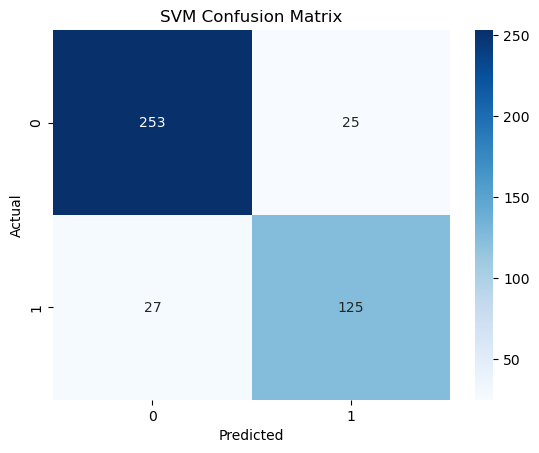

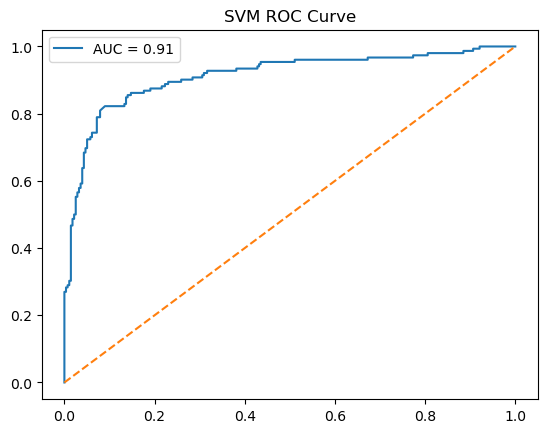

In [28]:
# Final prediction
y_pred_svm = (y_prob_svm >= best_thresh).astype(int)

# Evaluation
evaluate_model(y_test, y_pred_svm, y_prob_svm, name="SVM")

**Description**
- In `y_pred_svm`, the optimal threshold is applied to probabilities `(y_prob_svm)` to generate final predictions.
- The `evaluate_model()` function shows strong performance with **Accuracy: 88%, F1 Score: 0.83, and ROC-AUC: 0.91,** indicating a well-balanced SVM model.

# **2. Random Forest**

## **Model Training**
- The `RandomForestClassifier` is trained using the selected features `(X_train_sel)` and target variable `(y_train)`. The parameter `class_weight='balanced'` is used to handle class imbalance, while `random_state=42` ensures reproducibility of results.
- This model builds multiple decision trees and combines their outputs to improve prediction accuracy and reduce overfitting.

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_sel, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### **Hyperparameter Tuning**

- Different combinations of hyperparameters are tested to find the optimal balance between model complexity and performance.
- `n_estimators`: Number of trees in the forest.
- `max_depth`: Maximum depth of each tree.
- `min_samples_split`: Minimum samples required to split a node.
- These are used to optimize the **Random Forest** model by selecting the best hyperparameters based on ROC-AUC score with cross-validation.

In [30]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid_rf.fit(X_train_sel, y_train)

best_rf = grid_rf.best_estimator_

print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}


### **Cross Validation**

In [31]:
cv_scores_rf = cross_val_score(best_rf, X_train_sel, y_train, cv=5)

print("All CV scores:", cv_scores)
print("Cross Validation Accuracy:", cv_scores_rf.mean())

All CV scores: [0.86337209 0.83139535 0.82848837 0.84011628 0.89212828]
Cross Validation Accuracy: 0.9459081971659096


### **Threshold Tuning & Evaluation**

In [32]:
# Probabilities
y_prob_rf = best_rf.predict_proba(X_test_sel)[:, 1]

# Threshold tuning

best_thresh = 0
best_f1 = 0

for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (y_prob_rf >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1:", best_f1)

Best Threshold: 0.5
Best F1: 0.9333333333333332


Accuracy: 0.9534883720930233
Precision: 0.9459459459459459
Recall: 0.9210526315789473
F1 Score: 0.9333333333333332
ROC-AUC: 0.9439842862552064


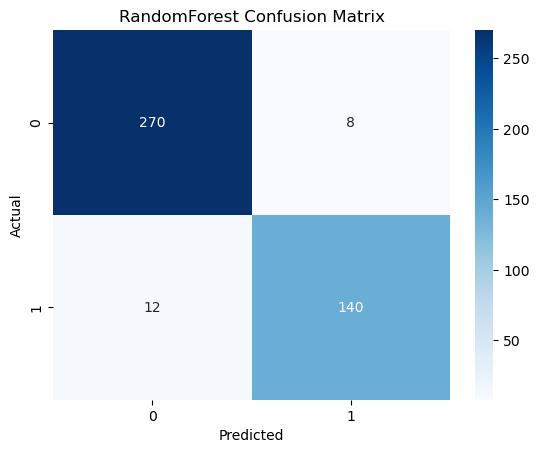

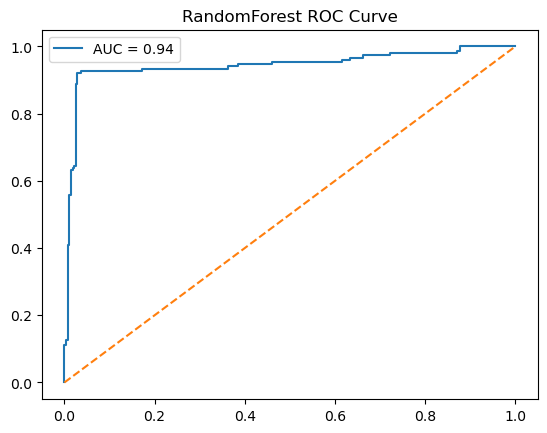

In [33]:
# Final Prediction
y_pred_rf = (y_prob_rf >= best_thresh).astype(int)
# Evaluation
evaluate_model(y_test, y_pred_rf, y_prob_rf , name="RandomForest")

**Description:**
- The random forest model shows a strong performance with **Accuracy of 95.3%, with Precision of 0.95, Recall of 0.92, F1 Score of 0.93, and a strong ROC-AUC of 0.94**, indicating a good performance of model on unseen data.

## **3. Logistic Regression**
- Another model **(The LogisticRegression model)** is trained on `X_train_sel` and `y_train` to learn the relationship between features and the target variable.
- `class_weight='balanced'` is used to handle class imbalance, and `max_iter=1000` ensures model convergence.

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_sel, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### **Hyperparameter Tuning**

Different combinations of hyperparameters are tested to find the optimal balance between model performance and generalization.
- `C`: Controls regularization strength
- `penalty`: Type of regularization applied to the model(`L2`)
- `solver`: Optimization algorithm used to find the best parameters(`lbfgs`)

In [35]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid_lr.fit(X_train_sel, y_train)

best_lr = grid_lr.best_estimator_

print("Best Params:", grid_lr.best_params_)

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


### **Cross Validation**

In [36]:
cv_scores_lr = cross_val_score(best_lr, X_train_sel, y_train, cv=5)

print("All CV scores:", cv_scores)
print("Cross Validation Accuracy:", cv_scores_lr.mean())

All CV scores: [0.86337209 0.83139535 0.82848837 0.84011628 0.89212828]
Cross Validation Accuracy: 0.8289816258729406


### **Threshold Tuning & Evaluation**

In [37]:
# Probabilities
y_prob_lr = best_lr.predict_proba(X_test_sel)[:, 1]

# Threshold tuning
best_thresh = 0
best_f1 = 0

for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_prob_lr >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1:", best_f1)

Best Threshold: 0.5
Best F1: 0.753623188405797


Accuracy: 0.8023255813953488
Precision: 0.6735751295336787
Recall: 0.8552631578947368
F1 Score: 0.753623188405797
ROC-AUC: 0.8848684210526316


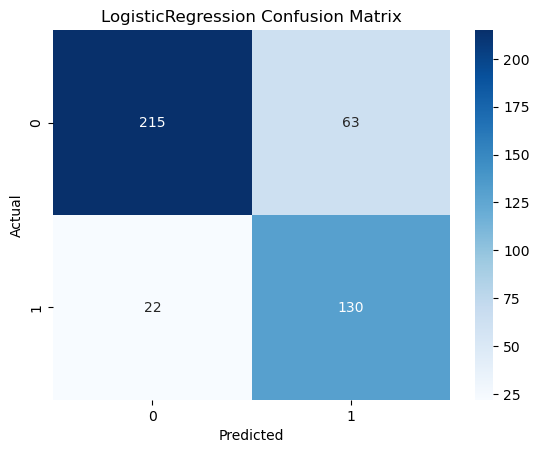

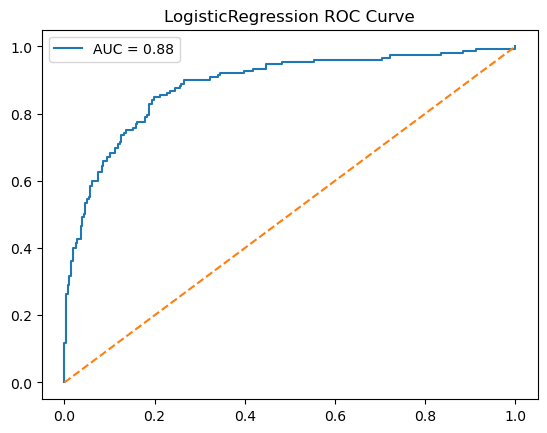

In [38]:
# Final Prediction
y_pred_lr = (y_prob_lr >= best_thresh).astype(int)

# Evaluation
evaluate_model(y_test, y_pred_lr, y_prob_lr, name="LogisticRegression")

**Description**
- The **Logistics regression** shows slightly lower performance than **random forest and SVM** with **Accuracy of 80%** and a **ROC-AUC of 0.88**.

## **4. XGBOOST Classifier**
- Another powerful model **XGBOOST Classifier** is used to trainthe model and evalute the performnce.
- A gradient boosting model that improves performance by learning from previous errors.

In [39]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 614.3 kB/s eta 0:00:000:01m00:09


### **Model Training**
- The `XGBClassifier` is trained on `X_train_sel` and `y_train` to build a powerful gradient boosting model for classification.
- `eval_metric='logloss'` is used to measure performance during training, and `random_state=42` ensures reproducibility

In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_sel, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### **Hyperparameter Tuning**
Different combinations of hyperparameters are tested to find the optimal balance between model performance and generalization.
- `n_estimators`: Number of boosting trees.
- `max_depth`: Maximum depth of each tree.
- `learning_rate`: Controls how much each tree contributes to the final model.

In [47]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_xgb = GridSearchCV(
    XGBClassifier( eval_metric='logloss', random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid_xgb.fit(X_train_sel, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best Params:", grid_xgb.best_params_)

Best Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}


### **Cross Validation**

In [48]:
cv_scores_xgb = cross_val_score(best_xgb, X_train_sel, y_train, cv=5)

print("All CV scores:", cv_scores)
print("Cross Validation Accuracy:", cv_scores_xgb.mean())

All CV scores: [0.86337209 0.83139535 0.82848837 0.84011628 0.89212828]
Cross Validation Accuracy: 0.944160621059055


### **Threshold Tuning & Evaluation**

In [50]:
# Probabilities
y_prob_xgb = best_xgb.predict_proba(X_test_sel)[:, 1]

# Best Threshold
best_thresh = 0
best_f1 = 0

for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_prob_xgb >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1:", best_f1)

Best Threshold: 0.5
Best F1: 0.9297658862876254


Accuracy: 0.9511627906976744
Precision: 0.9455782312925171
Recall: 0.9144736842105263
F1 Score: 0.9297658862876254
ROC-AUC: 0.949652120408936


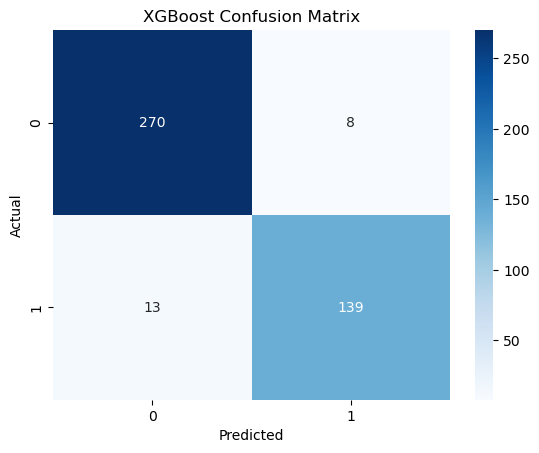

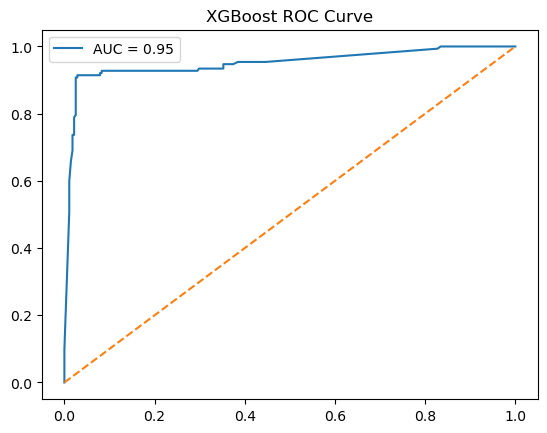

In [51]:
# Final Prediction
y_pred_xgb = (y_prob_xgb >= best_thresh).astype(int)

# Evaluation
evaluate_model(y_test, y_pred_xgb, y_prob_xgb, name="XGBoost")

**Description**
- **XGBoost** also performed very well with **Accuracy (95.1%)** and the highest **ROC-AUC (0.95)**, showing strong generalization ability.

## **All Models  Comparison (Dataframe)**

In [52]:
results = pd.DataFrame({
    "Model": ["SVM", "Random Forest", "Logistic Regression", "XGBoost"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0                  SVM  0.879070   0.833333  0.822368  0.827815  0.912202
1        Random Forest  0.953488   0.945946  0.921053  0.933333  0.943984
2  Logistic Regression  0.802326   0.673575  0.855263  0.753623  0.884868
3              XGBoost  0.951163   0.945578  0.914474  0.929766  0.949652


**Description**
- The results show a comparison of **four machine learning models** based on key evaluation metrics.
- **Random Forest** achieved the best overall performance with the **highest Accuracy (95.3%)**, **F1 Score (0.93)**, and strong **ROC-AUC (0.94)**, showing strong generalization ability among all models.
- **XGBoost** performed very well with **Accuracy (95.1%)** and the **highest ROC-AUC (0.95)**, indicating excellent and balanced predictions.
- **SVM** provided good results with moderate performance across all metrics, achieving an **Accuracy** of **88%** and **ROC-AUC:0.91**.
- **Logistic Regression** showed the lowest overall performance with **Accuracy: 80.2%** and **ROC-AUC 0.88**., though it maintained a relatively higher Recall, indicating better identification of positive cases.
- Overall, **Random Forest** and **XGBoost** outperform the other models and are the most suitable for this dataset.

## **ROC Curve Comparison (All Models)**

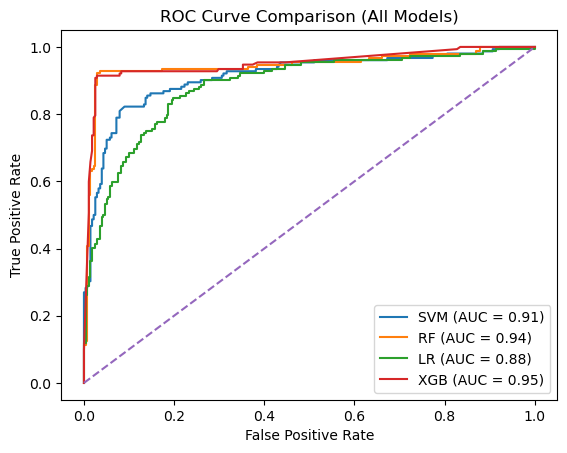

In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# XGBClassifier
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot all
plt.figure()

plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {auc_lr:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC = {auc_xgb:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], '--')

plt.title("ROC Curve Comparison (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid
plt.savefig("ROC_Comparison_allmodel.png", dpi=300, bbox_inches='tight')
plt.show()

## Conclusion
- In this project, **four machine learning models — SVM, Random Forest, Logistic Regression, and XGBoost** were trained for **Alzheimer’s disease** prediction using clinical and demographic features.
- A complete machine learning pipeline was implemented, which included **Exploratory Data Analysis (EDA)**, **data preprocessing, feature scaling, feature selection, model training, hyperparameter tuning, cross validation, Threshold tuning & evaluation** to ensure optimal performance.
- After this workflow, a performance comparison was conducted among all models. **Random Forest** achieved the best results with **Accuracy: 95.3%, F1 Score: 0.93,** and **ROC-AUC: 0.94**, closely followed by **XGBoost with Accuracy: 95.1%** and the **highest ROC-AUC: 0.95**.
- **SVM** showed moderate performance with **Accuracy: 88%,** and **ROC-AUC:0.91** while **Logistic Regression** performed comparatively lower with **Accuracy: 80.2%** and **ROC-AUC 0.88**.
- Overall, **Random Forest and XGBoost** demonstrated superior performance and were identified as the most effective models.